In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [2]:
import torch.nn as nn
import torch
from seqAE_model import SeqAutoencoder
from contra_seq_dataset import *
from torch.utils.data import DataLoader, RandomSampler
from tqdm import tqdm

def get_latents(model_tag, csv_name, load_bs=32):
    
    tag = model_tag
    bs = load_bs

    n_epochs = 30
    use_cuda = True
    empty_cuda = True
    cuda_ids = [0,1,2,3]
    model = SeqAutoencoder(dim_emb=512, heads=8, dim_hidden=32,
                           L_enc=6, L_dec=6, dim_ff=2048, 
                           drpt=0.1, actv='relu', eps=0.6, b_first=True)

    p = f'/home/kat/Repos/SALSA/results/models/{tag}/{n_epochs-1:02}.pt'
    model.load_state_dict(torch.load(p), strict = False)
    if empty_cuda:
        torch.cuda.empty_cache()
    if use_cuda:
        if len(cuda_ids) == 1:
            cuda_id = cuda_ids[0]
            device = torch.device(f"cuda:{cuda_id}")
        elif len(cuda_ids) > 1:
            device =  torch.device("cuda")
            print(f"Using {len(cuda_ids)} GPUs!")
            model = nn.DataParallel(model, device_ids=cuda_ids)
            model.to(device)
    else:
        device = torch.device("cpu")
        model = model.to(device)
    model = model.eval()
    print(f"Loaded model weights from {p}!")

    ds = ContraSeqDataset(csv_name)
    df = get_dataset_array(csv_name)

    loader = DataLoader(ds, batch_size=bs, sampler=range(len(df)), 
                        num_workers=0, pin_memory=True)
    latents = []
    for samp in tqdm(loader, total=len(df)//bs):
        for k,v in samp.items():
            if torch.is_tensor(v):
                samp[k] = v.to(device)
        latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                                  samp['avg_mask'], samp['out_mask'])
        latent = latent.cpu().detach().numpy()
        latents.append(latent)
    latents = np.concatenate(latents, axis=0)
    
    return latents

In [14]:
df = pd.read_csv('20220603_extended_augset_new.csv')

tags = ['2022041804_04',  # salsa
        '2022041807_a03', # contrastive  
        '2022041809_a04'] # vanilla ae

latents = get_latents(tags[0], csv_name='20220603_extended_augset_new.csv', load_bs=32)
print(df.shape, latents.shape)

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041804_04/29.pt!


703it [01:37,  7.18it/s]                         

(22485, 5) (22485, 32)


In [30]:
depths = [1,2,3]

# # # # # # # #
depth = 2
# # # # # # # #

depth_idc = df.index[[df.aug_iter==depth]].tolist()

df_depth = df.loc[depth_idc]
# latents_depth = latents[depth_idc]
print(df_depth.shape, latents_depth.shape)

(4610, 5) (3096, 32)


In [36]:
depths = [1,2,3,4,5]
depth_to_dists = {}

for depth in depths:

    depth_idc = df.index[[df.aug_iter==depth]].tolist()
    df_depth = df.loc[depth_idc]
    print(df_depth.shape, latents.shape)

    dists = []
    for i in df_depth.anc_idx.unique():

        anc_latent = latents[i]
        aug_idc = df_depth.index[[df_depth.anc_idx==i]].tolist() 
        aug_latents = latents[aug_idc]

        for aug_latent in aug_latents:
            d = distance.euclidean(anc_latent, aug_latent)
            dists.append(d)

    depth_to_dists[depth] = dists

(3096, 5) (22485, 32)
(4610, 5) (22485, 32)
(4757, 5) (22485, 32)
(4753, 5) (22485, 32)
(4769, 5) (22485, 32)


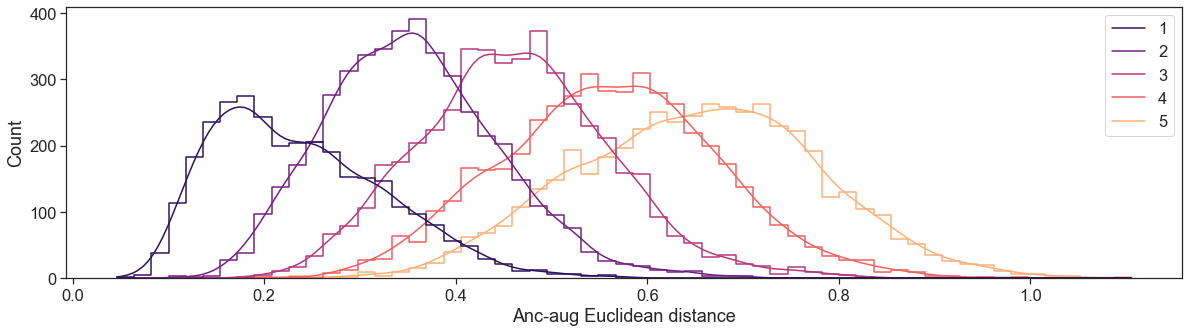

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(rc={'figure.figsize':(20,1)})
sns.set_theme(style='ticks',font_scale=1.5,palette='muted',)

plt.figure(figsize=(20,5))
sns.histplot(depth_to_dists, fill=False, element="step", kde=True, palette='magma')
# sns.displot(data=depth_to_dists, kind="kde")

plt.xlabel('Anc-aug Euclidean distance')
plt.show()

In [57]:
depth_to_dists

{1: [0.18286752700805664,
  0.21687428653240204,
  0.21128632128238678,
  0.1557808220386505,
  0.09303733706474304,
  0.13285551965236664,
  0.12655965983867645,
  0.24392066895961761,
  0.19491451978683472,
  0.19137626886367798,
  0.12259836494922638,
  0.19196051359176636,
  0.29026368260383606,
  0.3010104298591614,
  0.2835775911808014,
  0.21784608066082,
  0.24510109424591064,
  0.22656767070293427,
  0.29505613446235657,
  0.32070064544677734,
  0.2442513257265091,
  0.1344023495912552,
  0.16363058984279633,
  0.3091026842594147,
  0.17227788269519806,
  0.212983176112175,
  0.19718824326992035,
  0.4092358946800232,
  0.25257328152656555,
  0.18969497084617615,
  0.18642756342887878,
  0.1824653148651123,
  0.16800850629806519,
  0.21166303753852844,
  0.1482924371957779,
  0.17074260115623474,
  0.22555027902126312,
  0.233040452003479,
  0.15640202164649963,
  0.23008312284946442,
  0.19916029274463654,
  0.17460685968399048,
  0.38100096583366394,
  0.2663593292236328,
  

In [31]:
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial import distance

dists = []
for i in df_depth.anc_idx.unique():
    
    anc_latent = latents[i]
    
    aug_idc = df_depth.index[[df_depth.anc_idx==i]].tolist() 
#     print(aug_idc)
    aug_latents = latents[aug_idc]
    
    for aug_latent in aug_latents:
        d = distance.euclidean(anc_latent, aug_latent)
        dists.append(d)

In [32]:
df_depth

,idx,anc_idx,src_idx,aug_iter,smiles
3596,5008,0,503,2,CC(O)CN(N=O)C(C)CCN
3597,5004,0,503,2,CCC(C)N(N=O)C(C)C(C)O
3598,5001,0,503,2,CCC(CC)N(CC(C)O)N=O
3599,5022,0,502,2,CC(O)(O)CN(CCCN)N=O
3600,5014,0,507,2,CC(O)CN(CC(C)(C)C)N=O
...,...,...,...,...,...
8201,34039,499,5043,2,Cc1cc(=O)nc(CN(C)C(=O)c2cccc(C(=O)NCc3[nH]c(C)...
8202,34029,499,5041,2,Cc1cc(=O)nc(C(C)NC(=O)c2cccc(C(=O)NCc3[nH]c(C)...
8203,34032,499,5041,2,Cc1nc(=O)cc(CNC(=O)c2cccc(C(=O)NC(C)c3nc(=O)c(...
8204,34066,499,5038,2,Cc1cc(=O)nc(CNC(=O)c2cccc(C(=O)NC(C)(C)c3cc(=O...


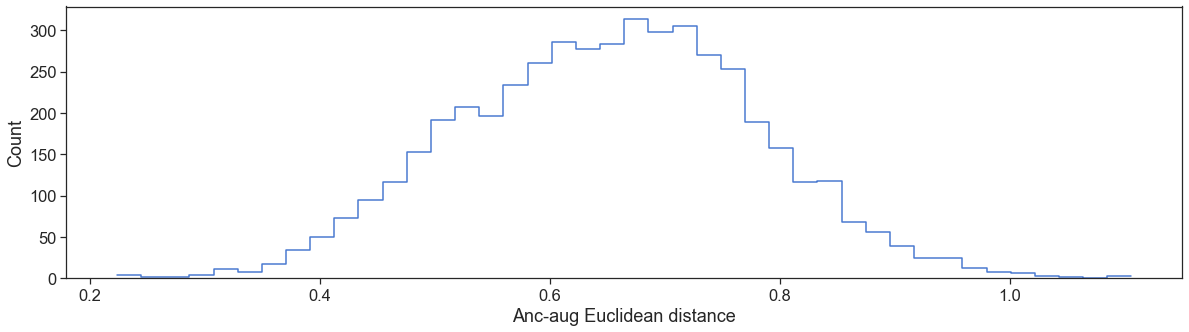

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.5,palette='muted')

plt.figure(figsize=(20,5))
sns.histplot(dists, fill=False, element="step", kde=False) #, bw_adjust=.25)
plt.xlabel('Anc-aug Euclidean distance')
plt.show()

In [34]:
dists_2 = dists

In [ ]:
def label(x, color, label):
    ax = plt.gca()
    t = ax.get_yaxis_transform()
    props = dict(boxstyle='square', facecolor='white', alpha=1., linewidth=1, edgecolor='white')
    ax.text(0.02, 12, label, fontsize='large', color='black',
            ha="left", va="bottom", transform=t, bbox=props)
    
    
# # # # # # # # # # # #
sns.set_theme(style='ticks',font_scale=2.25,palette='muted')

h = 3.5
asp = 4
pal = ['coral', '#EE9A00', '#FFC125','yellowgreen'] #  '#7D9EC0']

g = sns.FacetGrid(df, row="method", hue="method", aspect=asp, height=h, palette=pal)

# Draw the densities.
g.map(sns.kdeplot, "Pairwise anc-aug distances",
      clip_on=False, bw_adjust=.15,
      fill=True, alpha=.5, linewidth=3) # 1.5)
g.set_yticklabels([])

g.map(custom_vline,"Pairwise anc-aug distances")
g.map(label, "Pairwise anc-aug distances")

g.set_titles("")
g.set(ylabel="")
g.despine(bottom=False, left=False)
plt.savefig("anc_aug_dists_comparison_alpha_pt5.png")
display()